# RAG Baseline QA Performance

Evaluation of GPT-4o-mini RAG system on the QA task from RAGTruth.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

## Load Results

In [2]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

results = load_jsonl("../baselines/rag_baseline_answers.jsonl")
print(f"Total QA pairs evaluated: {len(results)}")

Total QA pairs evaluated: 100


## Answer Quality Metrics

In [3]:
def categorize_answer(answer):
    answer_lower = answer.lower()
    if 'cannot answer' in answer_lower or 'not enough information' in answer_lower:
        return 'Cannot Answer'
    elif len(answer.split()) < 5:
        return 'Very Short'
    elif len(answer.split()) < 20:
        return 'Short'
    elif len(answer.split()) < 50:
        return 'Medium'
    else:
        return 'Long'

categories = [categorize_answer(r['generated_answer']) for r in results]
category_counts = Counter(categories)

print("Answer Length Distribution:")
for cat, count in category_counts.most_common():
    print(f"  {cat}: {count} ({count/len(results)*100:.1f}%)")

answerable_rate = (len(results) - category_counts.get('Cannot Answer', 0)) / len(results)
print(f"\nAnswerable Rate: {answerable_rate*100:.1f}%")

Answer Length Distribution:
  Long: 70 (70.0%)
  Medium: 20 (20.0%)
  Cannot Answer: 10 (10.0%)

Answerable Rate: 90.0%


## Answer Length Distribution Chart

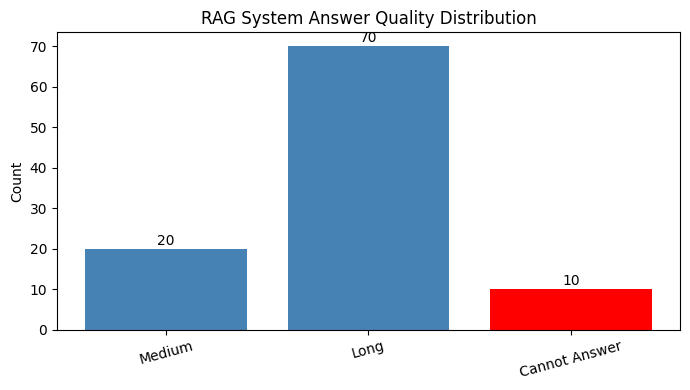

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
cats = list(category_counts.keys())
vals = list(category_counts.values())
colors = ['red' if c == 'Cannot Answer' else 'steelblue' for c in cats]
ax.bar(cats, vals, color=colors)
ax.set_ylabel('Count')
ax.set_title('RAG System Answer Quality Distribution')
for i, v in enumerate(vals):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Word Count Statistics

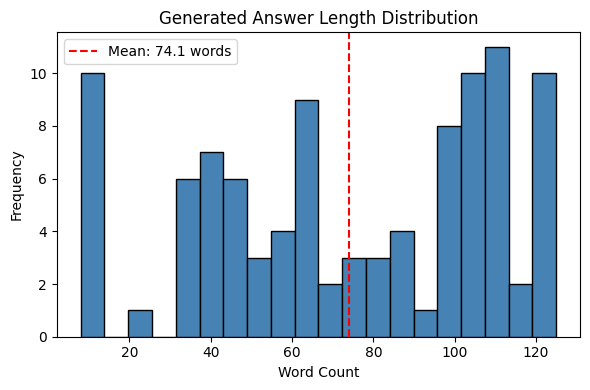

Average answer length: 74.1 words
Min: 8 words
Max: 125 words


In [5]:
word_counts = [len(r['generated_answer'].split()) for r in results]
avg_words = sum(word_counts) / len(word_counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(word_counts, bins=20, color='steelblue', edgecolor='black')
ax.axvline(avg_words, color='red', linestyle='--', label=f'Mean: {avg_words:.1f} words')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Generated Answer Length Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average answer length: {avg_words:.1f} words")
print(f"Min: {min(word_counts)} words")
print(f"Max: {max(word_counts)} words")

## Sample Answers

In [6]:
answerable = [r for r in results if 'cannot answer' not in r['generated_answer'].lower()][:3]
unanswerable = [r for r in results if 'cannot answer' in r['generated_answer'].lower()][:3]

print("=== Answerable Examples ===")
for i, r in enumerate(answerable, 1):
    print(f"\n{i}. Question: {r['question']}")
    print(f"   Answer: {r['generated_answer'][:150]}...")

print("\n=== Unanswerable Examples ===")
for i, r in enumerate(unanswerable, 1):
    print(f"\n{i}. Question: {r['question']}")
    print(f"   Answer: {r['generated_answer']}")

=== Answerable Examples ===

1. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through various compensation methods, including hourly rates and commission pay. The specific pay can depend on factor...

2. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through various compensation methods, including hourly rates and commission pay. The specifics of their pay can depend...

3. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through a variety of compensation methods, which can include hourly wages and commission pay rates. The specific pay c...

=== Unanswerable Examples ===

1. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passages.

2. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passages.

3. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passag

## Summary Statistics

In [7]:
summary_df = pd.DataFrame([
    {'Metric': 'Total Questions', 'Value': len(results)},
    {'Metric': 'Answerable', 'Value': f"{(answerable_rate*100):.1f}%"},
    {'Metric': 'Cannot Answer', 'Value': f"{(category_counts.get('Cannot Answer', 0)/len(results)*100):.1f}%"},
    {'Metric': 'Avg Answer Length', 'Value': f"{avg_words:.1f} words"}
])

print(summary_df.to_string(index=False))

           Metric      Value
  Total Questions        100
       Answerable      90.0%
    Cannot Answer      10.0%
Avg Answer Length 74.1 words
